# DTGS184. Figure 1d: Simulating Cell Nuclei

This notebook simulates a population of cell nuclei with DeepTrack2, reproducing the nuclei panel of Figure 1d. Nuclei are modeled as `dt.Ellipsoid` scatterers, spatially separated with `dt.NonOverlapping`, imaged through a fluorescence microscope, and converted into an instance-segmentation-style label mask with `dt.SampleToMasks`. The notebook generates two matching panels: the simulated composite image, and the ground-truth instance mask used to generate it.


In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.


In [2]:
import random

import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import label
from skimage import morphology as skmorph
from skimage.color import label2rgb

import deeptrack as dt


def seed_everything(seed: int = 123) -> None:
    random.seed(seed)
    np.random.seed(seed)


SEED = 123
seed_everything(SEED)

TILE_SIZE = 300
RESOLUTION = 0.656e-6  # 0.656 um/px


/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 1. Defining the Nucleus Shape

Each nucleus is an ellipsoid whose in-plane axes and thickness are drawn to match a realistic nuclear footprint (roughly 8-12 um).


In [3]:
def random_ellipsoid_axes():
    # Corrected to nuclear scale (~8.0-12.0 um footprint).
    ellipse_area = (np.random.uniform(8.0, 12.0)) ** 2
    radius_ratio = np.random.uniform(0.7, 1.4)
    major_axis = np.sqrt(ellipse_area) * radius_ratio
    minor_axis = np.sqrt(ellipse_area) / radius_ratio
    z_axis = np.sqrt(ellipse_area) * np.random.uniform(0.2, 0.4)
    return (major_axis, minor_axis, z_axis) * dt.units.um


## 2. Simulating the Sample

A random number of nuclei are placed within the tile, deformed with an elastic transformation, and blended with three noise components (long-range, short-range, and randomly-parameterized) to mimic realistic fluorescence texture. `dt.NonOverlapping` then resolves a non-overlapping arrangement of nuclei before imaging.


In [4]:
ellipse = dt.Ellipsoid(
    radius=random_ellipsoid_axes,
    intensity=lambda: np.random.uniform(0.5, 1.5),
    position=lambda: np.random.uniform(10, TILE_SIZE - 10, size=2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

synthetic_nuclei = (
    (ellipse ^ (lambda: np.random.randint(10, 12)))
    >> dt.Pad(px=(10, 10, 10, 10), keep_size=False)
    >> dt.ElasticTransformation(alpha=100, sigma=10, order=1)
    >> dt.CropTight()
)
synthetic_nuclei_mask = synthetic_nuclei > 0

long_range_noise = (
    synthetic_nuclei >> dt.Poisson(snr=0.2) >> dt.GaussianBlur(sigma=3.5)
)
short_range_noise = (
    synthetic_nuclei >> dt.Poisson(snr=1.0) >> dt.GaussianBlur(sigma=1.5)
)
random_range_noise = (
    synthetic_nuclei
    >> dt.Poisson(snr=lambda: np.random.uniform(0.5, 1.5))
    >> dt.GaussianBlur(sigma=lambda: np.random.uniform(0.75, 1.5))
)
noisy_synthetic_nuclei = (
    synthetic_nuclei_mask
    * (long_range_noise + short_range_noise + random_range_noise) / 3
)

non_overlap_nuclei = dt.NonOverlapping(noisy_synthetic_nuclei, min_distance=12)


## 3. Imaging the Sample

The non-overlapping nuclei are imaged with `dt.Fluorescence` using physically realistic microscopy parameters, then lightly blurred to simulate optical aliasing.


In [5]:
optics = dt.Fluorescence(
    resolution=RESOLUTION, magnification=1, wavelength=460e-9,
    NA=1.0,
    output_region=(0, 0, TILE_SIZE, TILE_SIZE),
)
sim_im_pip = (
    optics(non_overlap_nuclei)
    >> dt.Gaussian(sigma=lambda: np.random.uniform(0, 0.2))
)

# The NA/resolution combination can trigger a sampling warning, which can be ignored:
# aliasing is present in experimental data too, so we want to simulate it as well.


## 4. Building the Ground-Truth Mask

`dt.SampleToMasks` renders each nucleus into a binary mask, isotropically eroded to separate touching instances, and merged into a single label mask.


In [6]:
def get_mask(radius):
    """Apply isotropic erosion to a binary mask."""
    def inner(mask):
        mask = np.sum(mask, -1, keepdims=True) > 0
        mask = np.pad(mask, [(1, 1), (1, 1), (0, 0)], mode="constant")
        mask = skmorph.isotropic_erosion(mask, radius=radius)
        return mask[1:-1, 1:-1]
    return inner


sim_mask_pip = (
    non_overlap_nuclei
    >> dt.SampleToMasks(get_mask, radius=2, output_region=optics.output_region,
                       merge_method="or")
)


## 5. Resolving the Image and Mask Together

The image and mask pipelines are resolved jointly with `&` so that they share the same random draw of nuclei, then converted to PyTorch tensors and back to NumPy arrays.


In [7]:
sim_im_mask_pip = sim_im_pip & sim_mask_pip

image, mask = sim_im_mask_pip.update()()

/Users/cmanzo/Documents/GitHub/DeepTrack2/deeptrack/optical/optics.py:783: UserWarning: Likely bad optical parameters. NA / wavelength * 
                resolution / magnification = [1.42608696 1.42608696 1.42608696] should be at most 0.5. 
                To fix, set magnification to 3.0, and downsample
                the resulting image with 
                dt.AveragePooling((3.0, 3.0, 1))
                
  warnings.warn(


## 6. Plotting the Composite Image

The simulated image is shown with a physical scale bar, computed from the pixel resolution set above.


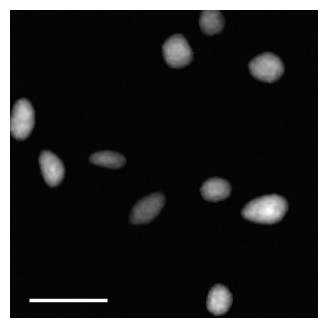

In [8]:
px_per_um = 1.0 / (RESOLUTION * 1e6)  # RESOLUTION is in meters/px
SCALE_BAR_UM = 50.0
scale_bar_px = SCALE_BAR_UM * px_per_um

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(image, cmap="gray")
x0, y0 = TILE_SIZE * 0.06, TILE_SIZE * 0.94
ax.plot([x0, x0 + scale_bar_px], [y0, y0], color="white", linewidth=2.5,
        solid_capstyle="butt")
ax.axis("off")

fig.savefig("fig1d_nuclei_sim.svg", format="svg", bbox_inches="tight",
            pad_inches=0, transparent=True)


## 7. Plotting the Ground-Truth Mask

The binary mask is labeled into connected components and colored per instance to give the ground-truth annotation for the composite image above.


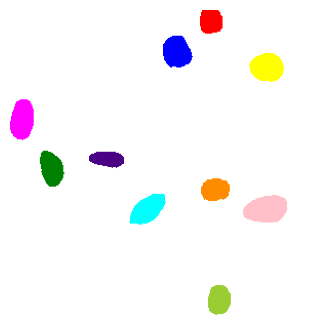

In [9]:
labeled, _ = label(mask.squeeze().astype(int))
composite_gt = label2rgb(labeled, bg_label=0, bg_color=(1, 1, 1))  # white background

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(composite_gt, cmap="nipy_spectral")
ax.axis("off")

fig.savefig("fig1d_nuclei_gt.svg", format="svg", bbox_inches="tight",
            pad_inches=0, transparent=True)
